1. verbose false
2. write agent 제외

In [1]:
# !pip install -q langchain==0.2.16
# !pip install -q ragas==0.1.19

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
from rag.pdf import PDFRetrievalChain

pdf = PDFRetrievalChain(["data/한글6법전.pdf"]).create_chain()

pdf_retriever = pdf.retriever
pdf_chain = pdf.chain

In [ ]:
from langgraph.graph import StateGraph
from typing import Type, TypedDict, Annotated
from crewai import Agent, Task, Crew
from crewai.process import Process
from langchain_openai import ChatOpenAI
from crewai.tools import tool
import os
from langchain_community.utilities import ArxivAPIWrapper

from tavily import TavilyClient
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig
import uuid



### Tool

In [5]:
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# 문서 평가를 위한 데이터 모델 정의
class GradeDocuments(BaseModel):
    """Binary score for relevance check on retrieved documents."""

    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )


# LLM 초기화 및 함수 호출을 통한 구조화된 출력 생성
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeDocuments)

# 시스템 메시지와 사용자 질문을 포함한 프롬프트 템플릿 생성
system = """You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the user question, grade it as relevant. \n
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""

grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Retrieved document: \n\n {document} \n\n User question: {question}"),
    ]
)

# 문서 검색결과 평가기 생성 
retrieval_grader = grade_prompt | structured_llm_grader


In [6]:
from crewai.tools import tool
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

# CrewAI가 사용하는 형태로 재정의
@tool("retriever_tool")
def retriever_tool(question: str) -> str:
    """2023년 12월에 출판된 AI 트렌드 PDF에서 정보를 검색하고, 관련성이 높은 결과만 반환합니다."""
    
    print("\n===[Retrieval TOOL, Search relevant_docs]===\n")
    
    # PDF에서 문서 검색
    docs = pdf_retriever.invoke(question)
    
    if not docs:
        return "관련된 문서를 찾지 못했습니다."

    # 검색된 문서 평가
    relevant_docs = []
    for doc in docs:
        grade_result = retrieval_grader.invoke({"document": doc.page_content, "question": question})
        if grade_result.binary_score == "yes":
            relevant_docs.append(doc)

    # 평가 후 관련 문서가 없다면 메시지 반환
    if not relevant_docs:
        return "질문과 관련성이 높지 않아 제외되었습니다."
    
    print(f"Final retrieved {len(relevant_docs)} relevant documents.\n")

    # 필터링된 문서들을 하나의 문자열로 반환
    return "\n\n".join([
        f"{doc.page_content}\n(출처: {doc.metadata.get('source', 'N/A')} / 페이지: {doc.metadata.get('page', 'N/A')})"
        for doc in relevant_docs
    ])

In [7]:
# Define other tools
@tool("tavily_tool")
def tavily_tool(keyword: str) -> str:
    """Collect recent news for the given query."""
    print("\n===[Web search]===\n")
    tavily_client = TavilyClient(api_key=os.environ['TAVILY_API_KEY'])
    search_results = tavily_client.search(query=keyword, topic="news", days=30)
    return search_results

@tool("academic_tool")
def academic_tool(query: str):
    """Academic paper search tool."""
    print("\n===[Arxiv Paper Search]===\n")
    arxiv = ArxivAPIWrapper()
    docs = arxiv.run(query)
    return docs

In [8]:
# Define LLM
llm = ChatOpenAI(model="gpt-4o-mini")

In [9]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# === 1. 메시지 상태 정의 ===
# Define the State class
class CrewAIState(TypedDict):
    question: Annotated[str, "The user's query to retrieve AI trend information"]
    documents: Annotated[list, "Retrieved documents related to the query"]
    generation: Annotated[str, "LLM generated answer"]
    agents_list: Annotated[list, "List of dynamically added agents"]
    
    # persona
    role: Annotated[str, "Role of the agent"]
    goal: Annotated[str, "Goal of the agent"]
    backstory: Annotated[str, "Backstory of the agent"]

In [10]:
def add_agents(state: CrewAIState) -> CrewAIState:
    """
    실행 시작 시 사용자의 입력을 받아 새로운 Agent를 추가하는 노드
    """
    # 기존 Agents 리스트 (없을 경우 빈 리스트)
    #updated_agents_list = state.get("agents_list", [])

    # 사용자의 입력값에서 `role`, `goal`, `backstory` 가져오기


    new_agent = {
        "role": state["role"],
        "goal": state["goal"],
        "backstory": state["backstory"]
    }

    # ✅ 새로운 Agent 추가 (기존 목록 유지)
    state["agents_list"].append(new_agent)

    return {
       "agents_list": state["agents_list"]
    }

In [11]:
# ✅ 초기 상태 정의
initial_state = {
    "role": "AI 윤리 연구원",
    "goal": "AI 윤리 및 정책을 연구하고 규제 방향을 분석합니다.",
    "backstory": "AI 윤리 및 법적 규제 전문가",
    "agents_list": []
}

# ✅ 함수 실행 (Agent 추가)
updated_state = add_agents(initial_state)

# ✅ 결과 출력
print(updated_state)


{'agents_list': [{'role': 'AI 윤리 연구원', 'goal': 'AI 윤리 및 정책을 연구하고 규제 방향을 분석합니다.', 'backstory': 'AI 윤리 및 법적 규제 전문가'}]}


In [12]:
# ✅ 새로운 Agent 정보 설정
updated_state["role"] = "AI 보안 전문가"
updated_state["goal"] = "AI 보안 및 위협 탐지를 연구하고 해결책을 제안합니다."
updated_state["backstory"] = "AI 보안 기술 전문가"

# ✅ 함수 실행 (두 번째 Agent 추가)
updated_state = add_agents(updated_state)

# ✅ 실행 결과 출력
print(updated_state)

{'agents_list': [{'role': 'AI 윤리 연구원', 'goal': 'AI 윤리 및 정책을 연구하고 규제 방향을 분석합니다.', 'backstory': 'AI 윤리 및 법적 규제 전문가'}, {'role': 'AI 보안 전문가', 'goal': 'AI 보안 및 위협 탐지를 연구하고 해결책을 제안합니다.', 'backstory': 'AI 보안 기술 전문가'}]}


In [13]:
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage
from langgraph.graph import StateGraph
from langgraph.graph.message import add_messages
from crewai import Agent, Task, Crew, Process
from langchain.chat_models import ChatOpenAI

# === 1. 메시지 상태 정의 ===
# class AgentState(TypedDict):
#     messages: Annotated[Sequence[BaseMessage], add_messages]

# === 2. LLM 모델 설정 ===
llm = ChatOpenAI(model="gpt-4o-mini")


# === 3. CrewAI 실행 함수 (LangGraph 노드) ===
def crewai(state: CrewAIState) -> CrewAIState:
    """
    AgentState에서 메시지를 가져와 CrewAI를 실행하고, 결과를 다시 상태에 추가하는 LangGraph 노드.
    """
    # 1. 메시지 상태에서 사용자 입력 메시지 추출
    # user_messages = [msg.content for msg in state["question"] if isinstance(msg, HumanMessage)]
    # # user_messages = [msg.content for msg in state["messages"] if isinstance(msg, HumanMessage)]
    # question = user_messages[-1] if user_messages else "최신 AI 기술 트렌드 조사 후 뉴스레터 작성해줘"
    
    question = state["question"]
    
    #지금은 2025년 3월입니다.


     # ✅ CrewAI Agents 리스트 생성 (state["agents_list"] 기반)
    agents = [
        Agent(
            role=agent_info["role"],
            goal=agent_info["goal"],
            backstory=agent_info["backstory"],
            # tools=[retriever_tool, tavily_tool, academic_tool],  # 필요하면 tools 추가 가능
            tools=[retriever_tool],  # 필요하면 tools 추가 가능
            verbose=False,
            max_iter=5,
            llm=llm,
        )
        for agent_info in state["agents_list"]
    ]

    if not agents:
        print("❌ 실행할 Agent가 없습니다. 최소 1명 이상의 Agent를 추가하세요.")
        return state

    # ✅ CrewAI Task 설정
    tasks = [
        Task(
            description=(
                "당신은 주어진 정보에 대하여 답변을 하는 RAG시스템을 제공합니다."
                f"'{question}'에 대해 당신이 가진 도구들을 최대한 활용해 신뢰할 수 있는 정보를 수집하세요. "
                "모르면 모른다고 답변하고, 틀린 답변이나 거짓말을 해선 안됩니다."
                "가능하면 출처도 포함하세요."
            ),
            # "특히 PDF, 논문, 뉴스 검색 도구를 통해 다양한 관점에서 정보를 확보하세요. "
            expected_output="주어진 질문에 대하여 올바른 답변",
            # expected_output="정보 요약 및 출처 포함된 조사 결과",
            agent=agent
        )
        for agent in agents
    ]



    # 4. Crew 정의 및 실행
    crew = Crew(
        agents= agents ,
        tasks= tasks ,
        verbose=False,
        process=Process.sequential,
        share_crew=True,
        memory=True,
    )

    # Crew 실행 후 결과 저장
    result = crew.kickoff()
    
    # 4. Crew 실행 결과에서 올바르게 'generation'을 추출
    generation = (
        "\n".join([str(res) for res in result]) if isinstance(result, list)  # 리스트 응답 처리
        else result.content if hasattr(result, "content")  # CrewAI 응답 객체 처리
        else str(result)  # 일반적인 경우
    )

    
    # 5. CrewAI 실행 결과 가져오기
    retrieved_text = retriever_tool.func(question)  # 기본 PDF 검색
    # news_text = tavily_tool.func(question)  # 최신 뉴스 검색
    # academic_text = academic_tool.func(question)  # 논문 검색

    documents = []

    # 🔍 `retriever_tool` 결과 추가
    if isinstance(retrieved_text, str) and retrieved_text.strip():
        documents.append({"content": retrieved_text, "source": "retriever_tool"})

    # # 🔍 `tavily_tool` 결과 추가 (최신 뉴스)
    # if isinstance(news_text, str) and news_text.strip():
    #     documents.append({"content": news_text, "source": "tavily_tool"})

    # # 🔍 `academic_tool` 결과 추가 (논문 검색)
    # if isinstance(academic_text, str) and academic_text.strip():
    #     documents.append({"content": academic_text, "source": "academic_tool"})    

    # 6. LangGraph 메시지 상태 업데이트 및 평가용 결과 구성
    print("🟢 [CrewAI 실행 완료]")
    print("📌 질문:", state["question"])
    print("📝 생성된 답변:\n", generation)
    print("📚 검색된 문서 수:", len(documents))


    # 6. LangGraph 메시지 상태 업데이트
    return {
        "question": state["question"],
        "generation": generation,
        "documents": documents  # ✅ CrewAI 실행 결과를 LangGraph에서 활용 가능하게 변환
    }

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14968\39890316.py:13: LangChainDeprecationWarning: The class `ChatOpenAI` was deprecated in LangChain 0.0.10 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-openai package and should be used instead. To use it run `pip install -U :class:`~langchain-openai` and import as `from :class:`~langchain_openai import ChatOpenAI``.
  llm = ChatOpenAI(model="gpt-4o-mini")


In [14]:
# ✅ CrewAIState의 초기 상태 설정
initial_state = {
    "question": "삼성전자가 개발한 생성형 AI는?",
    "agents_list": [
        {
            "role": "AI 연구원",
            "goal": "삼성전자의 AI 기술을 분석하고 발전 가능성을 연구합니다.",
            "backstory": "AI 및 머신러닝 전문가"
        }
    ],
}
updated_state = crewai(initial_state)

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-04-07 15:47:32][🚀 CREW 'CREW' STARTED, 679CB055-8E05-417D-A6E8-2E9BF0ADAA89]: 2025-04-07 15:47:32.465062
 
[2025-04-07 15:47:32][📋 TASK STARTED: 당신은 주어진 정보에 대하여 답변을 하는 RAG시스템을 제공합니다.'삼성전자가 개발한 생성형 AI는?'에 대해 당신이 가진 도구들을 최대한 활용해 신뢰할 수 있는 정보를 수집하세요. 모르면 모른다고 답변하고, 틀린 답변이나 거짓말을 해선 안됩니다.가능하면 출처도 포함하세요.]: 2025-04-07 15:47:32.562641
 
[2025-04-07 15:47:33][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-04-07 15:47:33.421908
 
[2025-04-07 15:47:33][🤖 LLM CALL STARTED]: 2025-04-07 15:47:33.422908
 
[2025-04-07 15:47:35][✅ LLM CALL COMPLETED]: 2025-04-07 15:47:35.462452
 
[2025-04-07 15:47:35][🤖 TOOL USAGE STARTED: 'RETRIEVER_TOOL']: 2025-04-07 15:47:35.463452

===[Retrieval TOOL, Search relevant_docs]===

Final retrieved 3 relevant documents.

 
[2025-04-07 15:47:52][✅ TOOL USAGE FINISHED: 'RETRIEVER_TOOL']: 2025-04-07 15:47:52.069005
 
[2025-04-07 15:47:52][🤖 LLM CALL STARTED]: 2025-04-07 15:47:52.070005
 
[2025-04-07 15:48:05][✅ LLM CALL COMPLETED]: 2025-04-07 15:48:05.855811
 
[2025-04-07 15:4

In [15]:
# 새로운 에이전트 목록 추가
new_agents = [
    {
        "role": "데이터 분석가",
        "goal": "AI 관련 데이터를 분석하여 인사이트를 도출합니다.",
        "backstory": "데이터 사이언스 및 AI 모델링 전문가"
    },
    {
        "role": "AI 윤리 및 법률 전문가",
        "goal": "AI 기술이 윤리적이고 법적으로 문제없이 운영될 수 있도록 검토합니다.",
        "backstory": "AI 윤리 및 법적 문제 연구"
    },

]

# 기존 상태에 새로운 에이전트들 추가
initial_state["agents_list"].extend(new_agents)

initial_state

{'question': '삼성전자가 개발한 생성형 AI는?',
 'agents_list': [{'role': 'AI 연구원',
   'goal': '삼성전자의 AI 기술을 분석하고 발전 가능성을 연구합니다.',
   'backstory': 'AI 및 머신러닝 전문가'},
  {'role': '데이터 분석가',
   'goal': 'AI 관련 데이터를 분석하여 인사이트를 도출합니다.',
   'backstory': '데이터 사이언스 및 AI 모델링 전문가'},
  {'role': 'AI 윤리 및 법률 전문가',
   'goal': 'AI 기술이 윤리적이고 법적으로 문제없이 운영될 수 있도록 검토합니다.',
   'backstory': 'AI 윤리 및 법적 문제 연구'}]}

In [16]:
# # CrewAI 실행
# updated_state = crewai(initial_state)

### Answer relevant 평가

In [17]:
# Hallucination: 없는 정보를 답변을 가지고 답변을 만들어 내는것
# Relevant: 만들어진 답변이 질문과 관련성이 있는지 판단하는것
from langchain_openai import ChatOpenAI

class GradeAnswer(BaseModel):
    """Binary scoring to evaluate the appropriateness of answers to questions"""

    binary_score: str = Field(
        description="Indicate 'yes' or 'no' whether the answer solves the question"
    )


# 함수 호출을 통한 LLM 초기화
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeAnswer)

# 프롬프트 설정p
system = """You are a grader assessing whether an answer addresses / resolves a question \n 
     Give a binary score 'yes' or 'no'. Yes' means that the answer resolves the question."""
answer_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "User question: \n\n {question} \n\n LLM generation: {generation}"),
    ]
)

# 프롬프트 템플릿과 구조화된 LLM 평가기를 결합하여 답변 평가기 생성
answer_grader = answer_prompt | structured_llm_grader

### Hallucination checker

In [18]:
# 할루시네이션 체크를 위한 데이터 모델 정의
class GradeHallucinations(BaseModel):
    """Binary score for hallucination present in generation answer."""

    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )


# 함수 호출을 통한 LLM 초기화
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
structured_llm_grader = llm.with_structured_output(GradeHallucinations)

# 프롬프트 설정
system = """You are assessing whether an AI-generated answer is based on the provided set of documents.

- If the answer is **mostly** supported by the documents (even if it includes minor additional information), return 'yes'.
- If the answer is **somewhat related but contains unverified or extra details**, return 'partial'.
- If the answer **contradicts or fabricates information**, return 'no'.

Think carefully about whether the additional information significantly changes the meaning of the answer.
If it does not, allow it as 'yes' or 'partial' instead of rejecting outright.
"""

# 프롬프트 템플릿 생성
hallucination_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}"),
    ]
)

# 환각 평가기 생성
hallucination_grader = hallucination_prompt | structured_llm_grader

In [19]:
def hallucination_check(state):
    print("==== [CHECK HALLUCINATIONS] ====")
    # 질문과 문서 검색 결과 가져오기
    question = state["question"] # 질문
    documents = state["documents"] # 검색된 문서
    generation = state["generation"] # 생성된 답변
    # retry_count = state.get("retry_count", 0)

    # 노드 실행 제한
    retry_count = state.get("retry_count", 0)  # 현재 재귀 횟수 확인
    not_relevant_count = state.get("not_relevant_count", 0)  # 관련성 실패 횟수 추적
    
    #  **재귀 횟수 초과 감지 → 강제 종료**
    if retry_count >= 3 or not_relevant_count >= 3:
        print("==== [MAX RECURSION REACHED: TERMINATING] ====")
        print(f"==== [QUESTION AND DOCUMENTS DO NOT MATCH] ====\nQuestion: {question}\nDocuments: {documents}")
        return "terminate"  # 🚨 강제 종료 신호
        
    # 환각 평가
    score = hallucination_grader.invoke(
        {"documents": documents, "generation": generation}
    )
    grade = score.binary_score

    # Hallucination 여부 확인
    if grade == "yes" or grade == "partial":  # "partial"이면 허용
        print("==== [DECISION: GENERATION IS GROUNDED IN DOCUMENTS] ====")

        # 답변의 관련성(Relevance) 평가
        print("==== [GRADE GENERATED ANSWER vs QUESTION] ====")
        score = answer_grader.invoke({"question": question, "generation": generation})
        grade = score.binary_score

        # 관련성 평가 결과에 따른 처리
        if grade == "yes":
            print("==== [DECISION: GENERATED ANSWER ADDRESSES QUESTION] ====")
            return "relevant" # END
        else:
            print("==== [DECISION: GENERATED ANSWER DOES NOT ADDRESS QUESTION] ====")
            state["not_relevant_count"] = not_relevant_count + 1  # ❗ 관련성 실패 횟수 증가
            return "not relevant" # Qurey Rewrites
    else:
        print("==== [DECISION: GENERATION IS NOT GROUNDED IN DOCUMENTS, RE-TRY] ====")
        state["retry_count"] = retry_count + 1  # ❗ 할루시네이션 실패 횟수 증가ㄴ
        return "hallucination" # CrewAI

### Query rewrite

In [20]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# LLM 초기화
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Query Rewriter 프롬프트 정의(자유롭게 수정이 가능합니다)
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent / meaning."""

# Query Rewriter 프롬프트 템플릿 생성
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

# Query Rewriter 생성
question_rewriter = re_write_prompt | llm | StrOutputParser()

In [21]:
# 질문 재작성 노드
def transform_query(state):
    print("==== [TRANSFORM QUERY] ====")
    # 질문과 문서 검색 결과 가져오기
    question = state["question"] # 질문
    documents = state["documents"] # 검색된 문서

    # 질문 재작성
    better_question = question_rewriter.invoke({"question": question})
    print("""===ReWrite: {better_question}===""")
    return {"documents": documents, "question": better_question}

In [22]:
from langgraph.graph import START, END, StateGraph
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(CrewAIState)

workflow.add_node("crewai", crewai)
workflow.add_node("transform_query", transform_query)  # 쿼리 변환

workflow.add_edge(START, "crewai")
workflow.add_conditional_edges(
    "crewai",
    hallucination_check,
    {
        #"hallucination": "crewai",  # Hallucination 발생 시 재생성
        "hallucination": END,  # Hallucination 발생 시 재생성
        "relevant": END,  # 답변의 관련성 여부 통과
        "not relevant": "transform_query",  # 답변의 관련성 여부 통과 실패 시 쿼리 변환
        "terminate": END,  # 🚨 강제 종료
    },
)
workflow.add_edge("transform_query", "crewai")


# 그래프 컴파일
app = workflow.compile(checkpointer=MemorySaver())

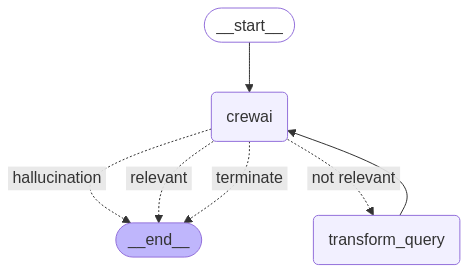

In [23]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [24]:
import pandas as pd
df = pd.read_csv("data/AIbrief_ragas_dataset.csv")
df.head()

,question,contexts,ground_truth,evolution_type,metadata,episode_done
0,What are the key considerations for the develo...,"['SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스...",The key considerations for the development and...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True
1,What is the purpose of the AAAI Conference?,['Ⅱ\n. 주요 행사 일정\n행사명 행사 주요 개요\n- 미국 소비자기술 협회(C...,The purpose of the AAAI Conference is to advan...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True
2,What role does artificial intelligence play in...,['1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국 연방거래...,The context discusses the role of artificial i...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True
3,What specific aspects of the AI development gu...,['∙ 첨단 AI 시스템의 성능과 한계를 공개하고 적절하거나 부적절한 사용영역을 알...,The AI development guidelines discussed at the...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True
4,How does AI privacy relate to G7 guidelines?,"['SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스...",The context does not provide specific informat...,reasoning,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True


In [25]:
from datasets import Dataset

test_dataset = Dataset.from_pandas(df)
test_dataset

Dataset({
    features: ['question', 'contexts', 'ground_truth', 'evolution_type', 'metadata', 'episode_done'],
    num_rows: 25
})

In [26]:
# === LangGraph 기반 RAG 평가용 실행 ===
import pandas as pd
from langchain_core.runnables import RunnableConfig
import uuid

# 질문 리스트 불러오기
#df = pd.read_csv("data/ragas_synthetic_dataset.csv")
questions = df["question"].tolist()

# 실행 결과 저장 리스트
answers = []
contexts = []

for q in questions:
    config = RunnableConfig(recursion_limit=20, configurable={"thread_id": uuid.uuid4()})
    
    input_state = {
        "question": q,
        "agents_list": [
            {
                "role": "AI 연구원",
                "goal": "기술을 분석하고 발전 가능성을 연구합니다.",
                "backstory": "AI 및 머신러닝 전문가"
            },
            {
                "role": "AI 윤리 및 법률 전문가",
                "goal": "AI 기술이 윤리적이고 법적으로 문제없이 운영될 수 있도록 검토합니다.",
                "backstory": "AI 윤리 및 법적 문제 연구"
            },
            {
                "role": "데이터 분석가",
                "goal": "AI 관련 데이터를 분석하여 인사이트를 도출합니다.",
                "backstory": "데이터 사이언스 및 AI 모델링 전문가"
            }
        ],
    }

    # 그래프 실행
    output = app.invoke(input_state, config=config)

    # ✅ 결과 저장 - LangGraph에서 리턴하는 key에 맞춰서!
    answers.append(output.get("generation", "")) # 위 generation이름으로 추가해야함
    contexts.append([doc["content"] for doc in output.get("documents", [])]) # 위 documents 이름으로 추가 해야함

# ragas 평가용 데이터프레임 구성
df["answer"] = answers
df["contexts"] = contexts

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-04-07 15:48:47][🚀 CREW 'CREW' STARTED, 276CF368-AFFC-45E0-930F-5B401E16F8B7]: 2025-04-07 15:48:47.125090
 
[2025-04-07 15:48:47][📋 TASK STARTED: 당신은 주어진 정보에 대하여 답변을 하는 RAG시스템을 제공합니다.'WHAT ARE THE KEY CONSIDERATIONS FOR THE DEVELOPMENT AND REGULATION OF ADVANCED AI SYSTEMS?'에 대해 당신이 가진 도구들을 최대한 활용해 신뢰할 수 있는 정보를 수집하세요. 모르면 모른다고 답변하고, 틀린 답변이나 거짓말을 해선 안됩니다.가능하면 출처도 포함하세요.]: 2025-04-07 15:48:47.144090
 
[2025-04-07 15:48:48][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-04-07 15:48:48.067130
 
[2025-04-07 15:48:48][🤖 LLM CALL STARTED]: 2025-04-07 15:48:48.067130
 
[2025-04-07 15:48:50][✅ LLM CALL COMPLETED]: 2025-04-07 15:48:50.686385
 
[2025-04-07 15:48:50][🤖 TOOL USAGE STARTED: 'RETRIEVER_TOOL']: 2025-04-07 15:48:50.686385

===[Retrieval TOOL, Search relevant_docs]===

Final retrieved 7 relevant documents.

 
[2025-04-07 15:49:13][✅ TOOL USAGE FINISHED: 'RETRIEVER_TOOL']: 2025-04-07 15:49:13.308909
 
[2025-04-07 15:49:13][🤖 LLM CALL STARTED]: 2025-04-07 15:49:13.308909
 
[2025-04-07 15:49:

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-04-07 15:50:54][🚀 CREW 'CREW' STARTED, 6B7BD071-D30A-46F2-8DDB-2EA65BACB2B2]: 2025-04-07 15:50:54.296639
 
[2025-04-07 15:50:54][📋 TASK STARTED: 당신은 주어진 정보에 대하여 답변을 하는 RAG시스템을 제공합니다.'WHAT IS THE PURPOSE OF THE AAAI CONFERENCE?'에 대해 당신이 가진 도구들을 최대한 활용해 신뢰할 수 있는 정보를 수집하세요. 모르면 모른다고 답변하고, 틀린 답변이나 거짓말을 해선 안됩니다.가능하면 출처도 포함하세요.]: 2025-04-07 15:50:54.315638
 
[2025-04-07 15:50:54][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-04-07 15:50:54.943333
 
[2025-04-07 15:50:54][🤖 LLM CALL STARTED]: 2025-04-07 15:50:54.944030
 
[2025-04-07 15:50:56][✅ LLM CALL COMPLETED]: 2025-04-07 15:50:56.222824
 
[2025-04-07 15:50:56][🤖 TOOL USAGE STARTED: 'RETRIEVER_TOOL']: 2025-04-07 15:50:56.223829

===[Retrieval TOOL, Search relevant_docs]===

Final retrieved 3 relevant documents.

 
[2025-04-07 15:51:16][✅ TOOL USAGE FINISHED: 'RETRIEVER_TOOL']: 2025-04-07 15:51:16.257363
 
[2025-04-07 15:51:16][🤖 LLM CALL STARTED]: 2025-04-07 15:51:16.257363
 
[2025-04-07 15:51:18][✅ LLM CALL COMPLETED]: 2025-04-07 15:51:18.

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


...

 
[2025-04-07 16:25:04][🚀 CREW 'CREW' STARTED, FE3150C2-55E4-4717-AB65-7C357553A822]: 2025-04-07 16:25:04.575424
 
[2025-04-07 16:25:04][📋 TASK STARTED: 당신은 주어진 정보에 대하여 답변을 하는 RAG시스템을 제공합니다.'HOW DOES IDC FORECAST THE AI SOFTWARE MARKET BY 2027?'에 대해 당신이 가진 도구들을 최대한 활용해 신뢰할 수 있는 정보를 수집하세요. 모르면 모른다고 답변하고, 틀린 답변이나 거짓말을 해선 안됩니다.가능하면 출처도 포함하세요.]: 2025-04-07 16:25:04.594423
 
[2025-04-07 16:25:05][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-04-07 16:25:05.296649
 
[2025-04-07 16:25:05][🤖 LLM CALL STARTED]: 2025-04-07 16:25:05.296649
 
[2025-04-07 16:25:06][✅ LLM CALL COMPLETED]: 2025-04-07 16:25:06.823225
 
[2025-04-07 16:25:06][🤖 TOOL USAGE STARTED: 'RETRIEVER_TOOL']: 2025-04-07 16:25:06.824226

===[Retrieval TOOL, Search relevant_docs]===

Final retrieved 4 relevant documents.

 
[2025-04-07 16:25:28][✅ TOOL USAGE FINISHED: 'RETRIEVER_TOOL']: 2025-04-07 16:25:28.532203
 
[2025-04-07 16:25:28][🤖 LLM CALL STARTED]: 2025-04-07 16:25:28.532203
 
[2025-04-07 16:25:32][✅ LLM CALL COMPLETED]: 2025-04-07

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-04-07 16:26:39][🚀 CREW 'CREW' STARTED, F37928DF-0342-4A7B-B926-CEAA798A2B01]: 2025-04-07 16:26:39.812657
 
[2025-04-07 16:26:39][📋 TASK STARTED: 당신은 주어진 정보에 대하여 답변을 하는 RAG시스템을 제공합니다.'WHAT IS THE IMPACT OF AI AGENTS ACCORDING TO BILL GATES?'에 대해 당신이 가진 도구들을 최대한 활용해 신뢰할 수 있는 정보를 수집하세요. 모르면 모른다고 답변하고, 틀린 답변이나 거짓말을 해선 안됩니다.가능하면 출처도 포함하세요.]: 2025-04-07 16:26:39.832656
 
[2025-04-07 16:26:40][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-04-07 16:26:40.784656
 
[2025-04-07 16:26:40][🤖 LLM CALL STARTED]: 2025-04-07 16:26:40.785657
 
[2025-04-07 16:26:41][✅ LLM CALL COMPLETED]: 2025-04-07 16:26:41.936671
 
[2025-04-07 16:26:41][🤖 TOOL USAGE STARTED: 'RETRIEVER_TOOL']: 2025-04-07 16:26:41.936671

===[Retrieval TOOL, Search relevant_docs]===

Final retrieved 2 relevant documents.

 
[2025-04-07 16:27:02][✅ TOOL USAGE FINISHED: 'RETRIEVER_TOOL']: 2025-04-07 16:27:02.216601
 
[2025-04-07 16:27:02][🤖 LLM CALL STARTED]: 2025-04-07 16:27:02.216601
 
[2025-04-07 16:27:08][✅ LLM CALL COMPLETED]: 2025-04

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-04-07 16:28:22][🚀 CREW 'CREW' STARTED, 1F8ED34C-4BD2-4820-9C5F-53F22EA3B9E3]: 2025-04-07 16:28:22.141755
 
[2025-04-07 16:28:22][📋 TASK STARTED: 당신은 주어진 정보에 대하여 답변을 하는 RAG시스템을 제공합니다.'WHY IS YOUTUBE REQUIRING LABELS FOR AI-GENERATED CONTENT?'에 대해 당신이 가진 도구들을 최대한 활용해 신뢰할 수 있는 정보를 수집하세요. 모르면 모른다고 답변하고, 틀린 답변이나 거짓말을 해선 안됩니다.가능하면 출처도 포함하세요.]: 2025-04-07 16:28:22.162755
 
[2025-04-07 16:28:22][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-04-07 16:28:22.870166
 
[2025-04-07 16:28:22][🤖 LLM CALL STARTED]: 2025-04-07 16:28:22.870166
 
[2025-04-07 16:28:24][✅ LLM CALL COMPLETED]: 2025-04-07 16:28:24.323755
 
[2025-04-07 16:28:24][🤖 TOOL USAGE STARTED: 'RETRIEVER_TOOL']: 2025-04-07 16:28:24.324755

===[Retrieval TOOL, Search relevant_docs]===

Final retrieved 2 relevant documents.

 
[2025-04-07 16:28:45][✅ TOOL USAGE FINISHED: 'RETRIEVER_TOOL']: 2025-04-07 16:28:45.638579
 
[2025-04-07 16:28:45][🤖 LLM CALL STARTED]: 2025-04-07 16:28:45.638579
 
[2025-04-07 16:28:53][✅ LLM CALL COMPLETED]: 2025-0

In [41]:
df.to_csv("data/ragas_dataset_only_retriever_tool_with_answer.csv", index=False)
df

,question,contexts,ground_truth,evolution_type,metadata,episode_done,answer
0,What are the key considerations for the develo...,"[1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고...",The key considerations for the development and...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The key considerations for the development and...
1,What is the purpose of the AAAI Conference?,[Ⅱ\n. 주요 행사 일정\n행사명 행사 주요 개요\n- 미국 소비자기술 협회(CT...,The purpose of the AAAI Conference is to advan...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The AAAI Conference on Artificial Intelligence...
2,What role does artificial intelligence play in...,"[기술/연구 4. 인력/교육\n미국 연방거래위원회, 저작권청에 소비자 보호와 경쟁 ...",The context discusses the role of artificial i...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The role of artificial intelligence (AI) in th...
3,What specific aspects of the AI development gu...,"[1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고...",The AI development guidelines discussed at the...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The AI Safety Summit discussed several key asp...
4,How does AI privacy relate to G7 guidelines?,"[SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스를...",The context does not provide specific informat...,reasoning,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The G7 has established an International Code o...
5,"What links AI risk mgmt, safety, and dev strat...","[인공지능 산업 동향 브리프\n1. 정책/법제\n▹ 미국, 안전하고 신뢰할 수 있는...",The context does not provide a direct answer t...,reasoning,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,"The links between AI risk management, safety, ..."
6,How does the GSM8k benchmark assess Tongyi Qia...,"[기술/연구 4. 인력/교육\n알리바바 클라우드, 최신 LLM ‘통이치엔원 2.0’...",The context does not provide specific informat...,multi_context,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The GSM8k benchmark assesses improvements in T...
7,What ethical risks come from using AI content ...,"[SPRi AI Brief |\n2023-12월호\n유튜브, 2024년부터 AI 생...",The answer to given question is not present in...,conditional,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The ethical risks associated with using AI con...
8,"How does content moderation affect AI dev, esp...",[질문과 관련성이 높지 않아 제외되었습니다.],The context discusses how content moderation i...,conditional,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,Content moderation plays a crucial role in AI ...
9,What role does the CTA (Consumer Technology As...,[Ⅱ\n. 주요 행사 일정\n행사명 행사 주요 개요\n- 미국 소비자기술 협회(CT...,The CTA (Consumer Technology Association) play...,simple,[{'source': '../data/SPRI_AI_Brief_2023??2?�호_...,True,The Consumer Technology Association (CTA) play...


In [29]:
------평가 데이터셋 생성


SyntaxError: invalid syntax (3380938676.py, line 1)

In [ ]:
# from ragas import evaluate
# from ragas.metrics import faithfulness, answer_relevancy, context_precision, context_recall
# from datasets import Dataset
# import pandas as pd
# import ast

# # 1️. CSV 파일을 pandas로 먼저 읽기
# df = pd.read_csv("data/ragas_eval_dataset_include_answer.csv")

# # 2. contexts 문자열을 리스트로 파싱
# df["contexts"] = df["contexts"].apply(ast.literal_eval)

# # ⭐️ 3. ground_truths 컬럼 만들기 (ragas 요구 포맷: list of strings)
# df["ground_truths"] = df["ground_truth"].apply(lambda x: [x])

# # 4. HuggingFace Dataset으로 변환
# dataset = Dataset.from_pandas(df)

# # 5. ragas 평가 실행
# result = evaluate(
#     dataset,
#     metrics=[faithfulness, answer_relevancy, context_precision, context_recall]
# )

# print(result)

c:\Users\skyop\JaehoNote\RAGAS\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Evaluating: 100%|██████████| 40/40 [01:05<00:00,  1.64s/it]


{'faithfulness': 0.3996, 'answer_relevancy': 0.9567, 'context_precision': 0.7500, 'context_recall': 0.6667}


In [ ]:
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_recall, context_precision
from datasets import Dataset
import ast

#dataset = Dataset.from_pandas(df[["question", "contexts", "answer", "ground_truth"]])
# 1️. CSV 파일을 pandas로 먼저 읽기
df = pd.read_csv("data/ragas_dataset_only_retriever_tool_with_answer.csv.csv")

# 2. contexts 문자열을 리스트로 파싱
df["contexts"] = df["contexts"].apply(ast.literal_eval)

# 3. HuggingFace Dataset으로 변환
dataset = Dataset.from_pandas(df)
# context_precision
result = evaluate(dataset, metrics=[faithfulness, answer_relevancy, context_recall, context_precision])
print(result)

# 일반 rag: 
# {'context_precision': 0.7500, 'faithfulness': 0.4493, 'answer_relevancy': 0.6980, 'context_recall': 0.6667}
# recursvie 300 , overap 20 결과:
# {'faithfulness': 0.4186, 'answer_relevancy': 0.9576, 'context_recall': 0.6667, 'context_precision': 0.7500}
# only retriever tool
# {'faithfulness': 0.8716, 'answer_relevancy': 0.9700, 'context_recall': 0.7367, 'context_precision': 0.6400}

Evaluating:   0%|          | 0/100 [00:00<?, ?it/s]

{'faithfulness': 0.8716, 'answer_relevancy': 0.9700, 'context_recall': 0.7367, 'context_precision': 0.6400}


In [42]:
result_df = result.to_pandas()
result_df.head()

,user_input,retrieved_contexts,response,reference,faithfulness,answer_relevancy,context_recall,context_precision
0,What are the key considerations for the develo...,"[1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고...",The key considerations for the development and...,The key considerations for the development and...,1.000000,1.000000,1.00,1.0
1,What is the purpose of the AAAI Conference?,[Ⅱ\n. 주요 행사 일정\n행사명 행사 주요 개요\n- 미국 소비자기술 협회(CT...,The AAAI Conference on Artificial Intelligence...,The purpose of the AAAI Conference is to advan...,1.000000,0.983210,1.00,1.0
2,What role does artificial intelligence play in...,"[기술/연구 4. 인력/교육\n미국 연방거래위원회, 저작권청에 소비자 보호와 경쟁 ...",The role of artificial intelligence (AI) in th...,The context discusses the role of artificial i...,1.000000,0.972288,1.00,1.0
3,What specific aspects of the AI development gu...,"[1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고...",The AI Safety Summit discussed several key asp...,The AI development guidelines discussed at the...,0.542857,0.960997,0.25,1.0
4,How does AI privacy relate to G7 guidelines?,"[SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스를...",The G7 has established an International Code o...,The context does not provide specific informat...,0.571429,0.934468,1.00,0.0


In [43]:
result_df.to_csv("data/ragas_dataset_only_retriever_tool_with_eval.csv", index=False)

In [35]:
result_df[["context_precision", "context_recall"]]

,context_precision,context_recall
0,1.0,1.000000
1,1.0,1.000000
2,1.0,1.000000
3,1.0,0.250000
4,0.0,1.000000
5,0.0,1.000000
6,0.0,1.000000
7,0.0,0.000000
8,0.0,0.000000
9,1.0,0.500000


In [36]:
dataset["answer"]

["The key considerations for the development and regulation of advanced AI systems include the following aspects:\n\n1. **Safety and Security Standards**: \n   - Establishing safety and security standards for AI systems is crucial. Companies developing powerful AI systems are required to share safety test results and key information about their systems with the government. This includes developing standards for verifying the safety and reliability of AI systems and establishing best practices for labeling AI-generated content.\n\n2. **Privacy Protection**: \n   - Ensuring the protection of personal data is a significant concern. Regulations must address how AI systems handle sensitive information and ensure compliance with privacy laws.\n\n3. **Equity and Civil Rights**: \n   - Measures must be taken to prevent discrimination and bias in AI applications, particularly in critical areas such as criminal justice, housing, and healthcare. This includes developing best practices for AI use 

In [37]:
dataset['contexts']

[['1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령 발표\nKEY Contents\nn 미국 바이든 대통령이 ‘안전하고 신뢰할 수 있는 AI 개발과 사용에 관한 행정명령’에 서명하고\n광범위한 행정 조치를 명시\nn 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자\n보호 △노동자 지원 △혁신과 경쟁 촉진 △국제협력을 골자로 함\n£바이든 대통령, AI 행정명령 통해 안전하고 신뢰할 수 있는 AI 개발과 활용 추진\nn 미국 바이든 대통령이 2023년 10월 30일 연방정부 차원에서 안전하고 신뢰할 수 있는 AI 개발과\n사용을 보장하기 위한 행정명령을 발표\n∙ 행정명령은 △AI의 안전과 보안 기준 마련 △개인정보보호 △형평성과 시민권 향상 △소비자 보호\n△노동자 지원 △혁신과 경쟁 촉진 △국제협력에 관한 내용을 포괄\nn (AI 안전과 보안 기준) 강력한 AI 시스템을 개발하는 기업에게 안전 테스트 결과와 시스템에 관한\n주요 정보를 미국 정부와 공유할 것을 요구하고, AI 시스템의 안전성과 신뢰성 확인을 위한 표준 및\nAI 생성 콘텐츠 표시를 위한 표준과 모범사례 확립을 추진\n∙ △1026 플롭스(FLOPS, Floating Point Operation Per Second)를 초과하는 컴퓨팅 성능 또는 생물학적\n서열 데이터를 주로 사용하고 1023플롭스를 초과하는 컴퓨팅 성능을 사용하는 모델 △단일 데이터센터에서\n1,000Gbit/s 이상의 네트워킹으로 연결되며 AI 훈련에서 이론상 최대 1020 플롭스를 처리할 수 있는\n컴퓨팅 용량을 갖춘 컴퓨팅 클러스터가 정보공유 요구대상\nn (형평성과 시민권 향상) 법률, 주택, 보건 분야에서 AI의 무책임한 사용으로 인한 차별과 편견 및 기타\n문제를 방지하는 조치를 확대\n∙ 형사사법 시스템에서 AI 사용 모범사례를 개발하고, 주택 임대 시 AI 알고리즘 차별을 막기 위한 명확

In [38]:
pd.DataFrame(dataset)

,question,contexts,ground_truth,evolution_type,metadata,episode_done,answer
0,What are the key considerations for the develo...,"[1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고...",The key considerations for the development and...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The key considerations for the development and...
1,What is the purpose of the AAAI Conference?,[Ⅱ\n. 주요 행사 일정\n행사명 행사 주요 개요\n- 미국 소비자기술 협회(CT...,The purpose of the AAAI Conference is to advan...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The AAAI Conference on Artificial Intelligence...
2,What role does artificial intelligence play in...,"[기술/연구 4. 인력/교육\n미국 연방거래위원회, 저작권청에 소비자 보호와 경쟁 ...",The context discusses the role of artificial i...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The role of artificial intelligence (AI) in th...
3,What specific aspects of the AI development gu...,"[1. 정책/법제 2. 기업/산업 3. 기술/연구 4. 인력/교육\n미국, 안전하고...",The AI development guidelines discussed at the...,simple,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The AI Safety Summit discussed several key asp...
4,How does AI privacy relate to G7 guidelines?,"[SPRi AI Brief |\n2023-12월호\nG7, 히로시마 AI 프로세스를...",The context does not provide specific informat...,reasoning,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The G7 has established an International Code o...
5,"What links AI risk mgmt, safety, and dev strat...","[인공지능 산업 동향 브리프\n1. 정책/법제\n▹ 미국, 안전하고 신뢰할 수 있는...",The context does not provide a direct answer t...,reasoning,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,"The links between AI risk management, safety, ..."
6,How does the GSM8k benchmark assess Tongyi Qia...,"[기술/연구 4. 인력/교육\n알리바바 클라우드, 최신 LLM ‘통이치엔원 2.0’...",The context does not provide specific informat...,multi_context,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The GSM8k benchmark assesses improvements in T...
7,What ethical risks come from using AI content ...,"[SPRi AI Brief |\n2023-12월호\n유튜브, 2024년부터 AI 생...",The answer to given question is not present in...,conditional,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,The ethical risks associated with using AI con...
8,"How does content moderation affect AI dev, esp...",[질문과 관련성이 높지 않아 제외되었습니다.],The context discusses how content moderation i...,conditional,[{'source': '../data/SPRI_AI_Brief_2023년12월호_F...,True,Content moderation plays a crucial role in AI ...
9,What role does the CTA (Consumer Technology As...,[Ⅱ\n. 주요 행사 일정\n행사명 행사 주요 개요\n- 미국 소비자기술 협회(CT...,The CTA (Consumer Technology Association) play...,simple,[{'source': '../data/SPRI_AI_Brief_2023??2?�호_...,True,The Consumer Technology Association (CTA) play...


In [39]:
dataset.to_pandas().to_csv("data/ragas_eval_dataset_only_retriever_tool_include_answer.csv", index=False)

In [ ]:
--

# RAG Chain 평가

In [ ]:
from langchain_community.document_loaders import PDFPlumberLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

loader = PDFPlumberLoader("./data/SPRI_AI_Brief_2023년12월호_F.pdf")
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=50)
documents = text_splitter.split_documents(docs)

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

vector_store = FAISS.from_documents(documents, embeddings)

retriever = vector_store.as_retriever()

prompt = PromptTemplate.from_template(
    """You are an assistant for question-answering tasks. 
Use the following pieces of retrieved context to answer the question. 
If you don't know the answer, just say that you don't know. 

#Context: 
{context}

#Question:
{question}

#Answer:"""
)

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

chain = (
    {"context": retriever, "question": RunnablePassthrough()}
     | prompt
     | llm
     | StrOutputParser()
)

In [ ]:
#batch_dataset에 question을 넣어줌
batch_dataset = [question for question in dataset["question"]]
batch_dataset[:3]

['What is the role of the David and Lucile Packard Foundation in relation to AI initiatives?',
 'What are the ethical considerations and potential risks of AI-generated content in the context of responsible AI innovation?',
 'What is the significance of AI risk management in the context of AI development and safety?']

In [ ]:
answer = chain.batch(batch_dataset)
answer[:3]

["I don't know.",
 'The ethical considerations and potential risks of AI-generated content in the context of responsible AI innovation include:\n\n1. **Consumer Protection and Competition**: There are concerns about the potential harm to creators and consumers due to AI-generated content. The Federal Trade Commission (FTC) has highlighted risks such as privacy violations, discrimination, and the automation of biases, which could lead to consumer deception and unfair competition.\n\n2. **Misrepresentation**: AI-generated content may mislead consumers into believing that certain works were created by specific individuals, which can damage the reputation of creators and devalue their works. This raises issues related to copyright and the integrity of creative works.\n\n3. **Security and Privacy**: The implementation of strong security controls is essential to protect against insider threats, cyber threats, and physical security risks throughout the AI lifecycle. This includes ensuring tha

In [ ]:
# "answer" 컬럼 덮어쓰기 또는 추가
if "answer" in dataset.column_names:
    dataset = dataset.remove_columns(["answer"]).add_column("answer", answer)
else:
    dataset = dataset.add_column("answer", answer)

In [ ]:
# answer가 추가된건을 확인할 수 있다.
dataset

Dataset({
    features: ['question', 'contexts', 'ground_truth', 'evolution_type', 'metadata', 'episode_done', 'answer'],
    num_rows: 10
})

In [ ]:
from ragas import evaluate
from ragas.metrics import (
    answer_relevancy,
    faithfulness,
    context_recall,
    context_precision
)

result = evaluate(
    dataset=dataset,
    metrics=[
        faithfulness,
        answer_relevancy,
        context_precision,
        context_recall
    ]
)

Evaluating: 100%|██████████| 40/40 [00:52<00:00,  1.30s/it]


In [ ]:
result

{'context_precision': 0.7500, 'faithfulness': 0.4493, 'answer_relevancy': 0.6980, 'context_recall': 0.6667}

In [ ]:
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig
import uuid

# config 설정(재귀 최대 횟수, thread_id)
config = RunnableConfig(recursion_limit=10, configurable={"thread_id": uuid.uuid4()})

# 질문 입력
input_state = {
    "question": "삼성전자가 개발한 생성형 AI는?",
    "agents_list": [
        {
            "role": "AI 연구원",
            "goal": "삼성전자의 AI 기술을 분석하고 발전 가능성을 연구합니다.",
            "backstory": "AI 및 머신러닝 전문가"
        }
    ],
}


# 그래프 실행
stream_graph(app, input_state, config, ["crewai", "rewrite", "generate"])

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-03-20 01:46:43][🚀 CREW 'CREW' STARTED, FB8A01FC-3C79-4D68-8439-AF5D48570E38]: 2025-03-20 01:46:43.056369
 
[2025-03-20 01:46:43][📋 TASK STARTED: AI 연구원이 수행해야 할 연구 과제를 수행하세요.]: 2025-03-20 01:46:43.072370
 
[2025-03-20 01:46:44][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-03-20 01:46:44.717839
# Agent: AI 연구원
## Task: AI 연구원이 수행해야 할 연구 과제를 수행하세요.
 
[2025-03-20 01:46:44][🤖 LLM CALL STARTED]: 2025-03-20 01:46:44.717839
 
[2025-03-20 01:46:46][✅ LLM CALL COMPLETED]: 2025-03-20 01:46:46.146145
 
[2025-03-20 01:46:46][🤖 TOOL USAGE STARTED: 'TAVILY_TOOL']: 2025-03-20 01:46:46.147145
===[웹 검색]===
 
[2025-03-20 01:46:48][✅ TOOL USAGE FINISHED: 'TAVILY_TOOL']: 2025-03-20 01:46:48.802666


# Agent: AI 연구원
## Using tool: tavily_tool
## Tool Input: 
"{\"keyword\": \"Samsung AI technology advancements\"}"
## Tool Output: 
{'query': 'Samsung AI technology advancements', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.rcrwireless.com/20250310/featured/samsun

In [ ]:
new_agents = [
    {
        "role": "데이터 분석가",
        "goal": "AI 관련 데이터를 분석하여 인사이트를 도출합니다.",
        "backstory": "데이터 사이언스 및 AI 모델링 전문가"
    },
    {
        "role": "AI 윤리 및 법률 전문가",
        "goal": "AI 기술이 윤리적이고 법적으로 문제없이 운영될 수 있도록 검토합니다.",
        "backstory": "AI 윤리 및 법적 문제 연구"
    },

]

# 기존 리스트에 새로운 에이전트 추가
input_state["agents_list"].extend(new_agents)

input_state

{'question': '삼성전자가 개발한 생성형 AI는?',
 'agents_list': [{'role': 'AI 연구원',
   'goal': '삼성전자의 AI 기술을 분석하고 발전 가능성을 연구합니다.',
   'backstory': 'AI 및 머신러닝 전문가'},
  {'role': '데이터 분석가',
   'goal': '삼성전자의 AI 관련 데이터를 분석하여 인사이트를 도출합니다.',
   'backstory': '데이터 사이언스 및 AI 모델링 전문가'},
  {'role': 'AI 윤리 및 법률 전문가',
   'goal': 'AI 기술이 윤리적이고 법적으로 문제없이 운영될 수 있도록 검토합니다.',
   'backstory': 'AI 윤리 및 법적 문제 연구'}]}

In [ ]:
# 그래프 실행
stream_graph(app, input_state, config, ["crewai", "rewrite", "generate"])

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-03-20 01:48:40][🚀 CREW 'CREW' STARTED, FAE19323-CD10-4B59-989C-1DE654374092]: 2025-03-20 01:48:40.590196
 
[2025-03-20 01:48:40][📋 TASK STARTED: AI 연구원이 수행해야 할 연구 과제를 수행하세요.]: 2025-03-20 01:48:40.625196
 
[2025-03-20 01:48:42][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-03-20 01:48:42.465242
# Agent: AI 연구원
## Task: AI 연구원이 수행해야 할 연구 과제를 수행하세요.
 
[2025-03-20 01:48:42][🤖 LLM CALL STARTED]: 2025-03-20 01:48:42.465242
 
[2025-03-20 01:48:43][✅ LLM CALL COMPLETED]: 2025-03-20 01:48:43.274325
 
[2025-03-20 01:48:43][🤖 TOOL USAGE STARTED: 'TAVILY_TOOL']: 2025-03-20 01:48:43.275378
===[웹 검색]===
 
[2025-03-20 01:48:44][✅ TOOL USAGE FINISHED: 'TAVILY_TOOL']: 2025-03-20 01:48:44.367748


# Agent: AI 연구원
## Thought: I need to gather relevant information about Samsung's AI technology and its potential for advancement. This will help me create a comprehensive research report that meets the expected criteria.
## Using tool: tavily_tool
## Tool Input: 
"{\"keyword\": \"Samsung AI technology advancem

Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types
Invalid type NoneType for attribute 'crew_inputs' value. Expected one of ['bool', 'str', 'bytes', 'int', 'float'] or a sequence of those types


 
[2025-03-20 01:50:23][🚀 CREW 'CREW' STARTED, C9F9DBB5-6CEE-4A39-B89D-B6F989BA300E]: 2025-03-20 01:50:23.910649
 
[2025-03-20 01:50:23][📋 TASK STARTED: AI 연구원이 수행해야 할 연구 과제를 수행하세요.]: 2025-03-20 01:50:23.929646
 
[2025-03-20 01:50:24][🤖 AGENT 'AI 연구원' STARTED TASK]: 2025-03-20 01:50:24.793041
# Agent: AI 연구원
## Task: AI 연구원이 수행해야 할 연구 과제를 수행하세요.
 
[2025-03-20 01:50:24][🤖 LLM CALL STARTED]: 2025-03-20 01:50:24.793041
 
[2025-03-20 01:50:25][✅ LLM CALL COMPLETED]: 2025-03-20 01:50:25.765427
 
[2025-03-20 01:50:25][🤖 TOOL USAGE STARTED: 'TAVILY_TOOL']: 2025-03-20 01:50:25.765427
===[웹 검색]===
 
[2025-03-20 01:50:28][✅ TOOL USAGE FINISHED: 'TAVILY_TOOL']: 2025-03-20 01:50:28.209669


# Agent: AI 연구원
## Thought: I need to gather recent insights and advancements related to Samsung's AI technology to compile a comprehensive research report. I will start by collecting recent news articles that provide relevant information.
## Using tool: tavily_tool
## Tool Input: 
"{\"keyword\": \"Samsung AI t

In [ ]:
# from langchain_teddynote.messages import stream_graph
# from langchain_core.runnables import RunnableConfig
# import uuid

# # config 설정(재귀 최대 횟수, thread_id)
# config = RunnableConfig(recursion_limit=20, configurable={"thread_id": uuid.uuid4()})

# # 질문 입력
# input_state = {
#     "question": "현재 pdf에 대해서 요약해줘",
#     "agents_list": [
#         {
#             "role": "AI 연구원",
#             "goal": "삼성전자의 AI 기술을 분석하고 발전 가능성을 연구합니다.",
#             "backstory": "AI 및 머신러닝 전문가"
#         }
#     ],
# }


# # 그래프 실행
# stream_graph(app, input_state, config, ["crewai", "rewrite", "generate"])

NameError: name 'app' is not defined